# 04 - ResNet feature extractor + anomaly scoring

Terceiro modelo (Project 2). Abordagem **nao supervisionada** baseada em features de uma rede **pre-treinada** (ResNet18 no ImageNet), sem treinar nada:

1. extrai um vetor de features (512-dim) de cada imagem com a ResNet;
2. ajusta a distribuicao das imagens **normais** (media + covariancia);
3. pontua cada imagem de teste pela **distancia de Mahalanobis** a essa distribuicao (longe = anomalia).

E a base de metodos como o PaDiM/SPADE. Costuma dar AUROC mais alto que o autoencoder.

In [1]:
import numpy as np
import torch
from pathlib import Path
from PIL import Image
from torchvision import transforms
from torchvision.models import resnet18, ResNet18_Weights
from sklearn.covariance import LedoitWolf
from sklearn.metrics import roc_auc_score

device = "cuda" if torch.cuda.is_available() else "cpu"
print("A usar:", device)

# ResNet18 pre-treinada, sem a camada final (fica o vetor de 512 features)
resnet = resnet18(weights=ResNet18_Weights.DEFAULT)
resnet.fc = torch.nn.Identity()
resnet.eval().to(device)

preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])
print("ResNet18 pronta.")

A usar: cuda


ResNet18 pronta.


## 1. Extrair features

Features das imagens normais de treino e das imagens de teste (normais + defeituosas).

In [2]:
root = Path("../data/mvtec/bottle")

def extrair(paths):
    feats = []
    with torch.no_grad():
        for p in paths:
            img = Image.open(p).convert("RGB")
            x = preprocess(img).unsqueeze(0).to(device)
            feats.append(resnet(x).squeeze(0).cpu().numpy())
    return np.array(feats)

# Treino: so imagens normais
train_paths = sorted((root / "train" / "good").glob("*.png"))
train_feats = extrair(train_paths)

# Teste: normais + defeituosas
test_paths, test_labels = [], []
for sub in sorted((root / "test").iterdir()):
    if not sub.is_dir():
        continue
    label = 0 if sub.name == "good" else 1
    for p in sorted(sub.glob("*.png")):
        test_paths.append(p)
        test_labels.append(label)
test_feats = extrair(test_paths)
test_labels = np.array(test_labels)

print("Features treino:", train_feats.shape, "| teste:", test_feats.shape)

Features treino: (209, 512) | teste: (83, 512)


## 2. Ajustar a distribuicao normal e pontuar (Mahalanobis)

In [3]:
# LedoitWolf estima media + covariancia robusta (com shrinkage) das imagens normais
cov = LedoitWolf().fit(train_feats)

# Distancia de Mahalanobis ao quadrado = score de anomalia
scores = cov.mahalanobis(test_feats)

auroc = roc_auc_score(test_labels, scores)
print(f"Image-level AUROC (ResNet + Mahalanobis): {auroc:.4f}")

Image-level AUROC (ResNet + Mahalanobis): 0.9968


## 3. Exemplos com score de anomalia

Grelha de imagens de teste com o score de Mahalanobis e o veredito. O threshold e o **ponto de operacao otimo da curva ROC** (o que melhor separa normais de defeitos). Verde = acertou, vermelho = errou.

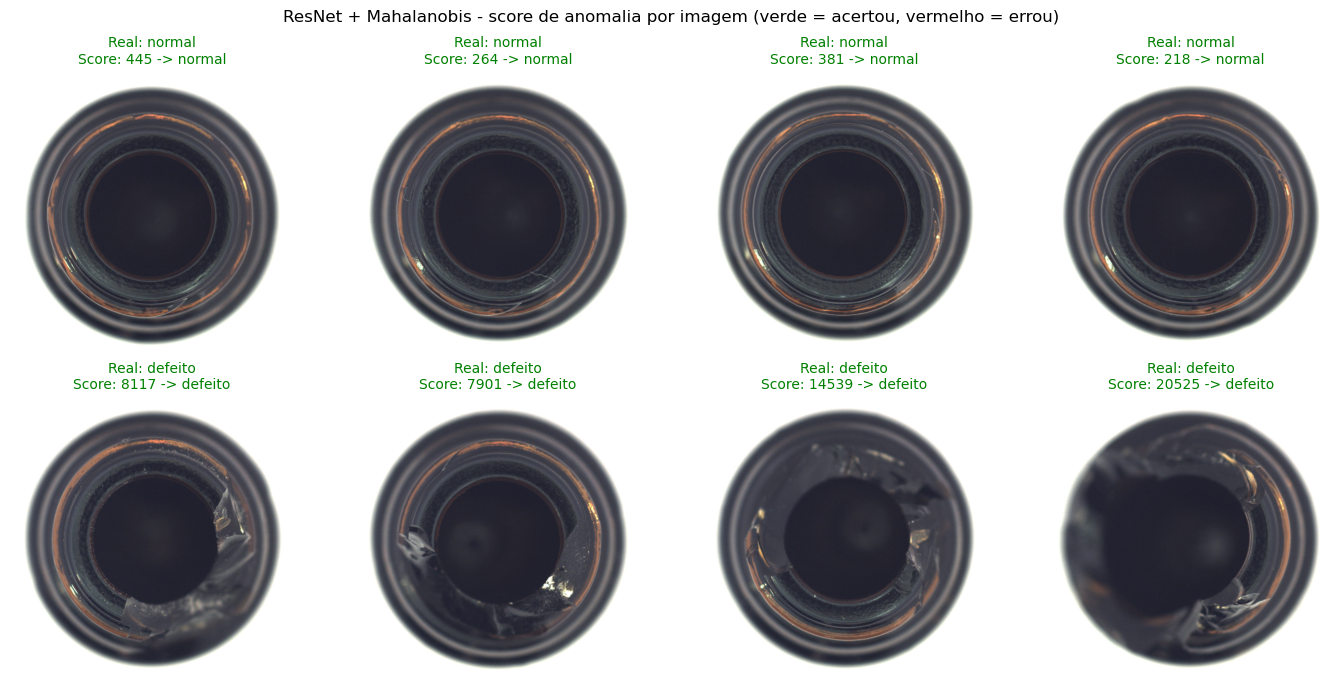

In [4]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

# Threshold = ponto de operacao otimo da ROC (Youden J): o que melhor separa normais de defeitos
fpr, tpr, ths = roc_curve(test_labels, scores)
limiar = float(ths[np.argmax(tpr - fpr)])
nomes = ['normal', 'defeito']

idx = np.concatenate([np.where(test_labels == 0)[0][:4], np.where(test_labels == 1)[0][:4]])

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax, i in zip(axes.ravel(), idx):
    img = Image.open(test_paths[i]).convert("RGB")
    prev = 1 if scores[i] >= limiar else 0
    cor = 'green' if prev == test_labels[i] else 'red'
    ax.imshow(img); ax.axis('off')
    ax.set_title(f"Real: {nomes[test_labels[i]]}\nScore: {scores[i]:.0f} -> {nomes[prev]}", color=cor, fontsize=10)

plt.suptitle("ResNet + Mahalanobis - score de anomalia por imagem (verde = acertou, vermelho = errou)", fontsize=12)
plt.tight_layout()
plt.show()